In [1]:
import pandas as pd

In [2]:
df1 = pd.read_csv('datasets/tieliikenneonnettomuudet_2024/tieliikenneonnettomuudet_2024_onnettomuudet.csv', sep=';', na_values=['', ' ', '-'])

In [3]:
df2 = pd.read_csv('datasets/tieliikenneonnettomuudet_2023/tieliikenneonnettomuudet_2023_onnettomuudet.csv', sep=';', na_values=['', ' ', '-'])

In [4]:
df1= df1.rename(columns={'Maakunta (koordinaattien perusteella)' : 'Maakunta', 'Nro' : 'Onnettomuustyyppi nro'})
df1 = df1.drop(columns='Elinvoimakeskus')
df2 = df2.drop(columns=['KVL', 'KVL raskas', 'Näkemä% yli 150', 'Näkemä% yli 300', 'Näkemä% yli 450', 'Näkemän pituus', 'Osallisten lkm'])
df2 = df2.rename(columns={'Maakunta ' : 'Maakunta'})

In [5]:
# Base data
df_original = pd.concat([df1, df2], ignore_index=True)

In [6]:
uusimaa = df_original[df_original["Maakunta"] == "Uusimaa"]
uusimaa = uusimaa[(uusimaa["Vakavuus"] == "Loukkaantumiseen johtanut") | (uusimaa["Vakavuus"] == "Vakavaan loukkaantumiseen johtanut") | (uusimaa["Vakavuus"] == "Kuolemaan johtanut")]
uusimaa

,OnnettomuusID,Tienpitäjä,Tieosoite,Ajorata,Tie,Osa,Etaisyys,x-koordinaatti,y-koordinaatti,Liikennevalot,...,Valoisuus,Lämpötila,Sää,Nopeusrajoitus,Verkollinen asema,Päällyste,Talvihoitoluokitus,Toiminallinen luokka korjattu,Rautatie,Taajama
31,630383,Kunta,NaN,NaN,NaN,NaN,NaN,392017.0,6685318.0,NaN,...,päivänvalo,−18,kirkas,40.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
38,630390,Kunta,NaN,NaN,NaN,NaN,NaN,392858.0,6681503.0,NaN,...,päivänvalo,−17,pilvipouta,50.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
39,630391,Väylävirasto,1371/1/648,0.0,1371.0,1.0,648.0,389089.0,6687040.0,NaN,...,tie valaistu,−20,lumisade,50.0,Tieto puuttuu,muu,Ise,Yhdystie,Ei tasoristeystä,kyllä
51,630403,Kunta,NaN,NaN,NaN,NaN,NaN,383665.0,6671405.0,toiminnassa,...,tie valaistu,−17,kirkas,50.0,NaN,kestopäällyste,NaN,Katu/Yksityistie,Ei tasoristeystä,kyllä
77,630432,Väylävirasto,130/4/5,0.0,130.0,4.0,5.0,379482.0,6697489.0,NaN,...,tie valaistu,−20,pilvipouta,80.0,NaN,kestopäällyste,Is,Seututie,Ei tasoristeystä,ei
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17692,630131,Väylävirasto,11763/1/8214,0.0,11763.0,1.0,8214.0,416339.0,6722956.0,NaN,...,pimeä (valaisematon),−10,sumu,50.0,NaN,sora,II,Yhdystie,Ei tasoristeystä,ei
17801,630244,Väylävirasto,101/8/2411,1.0,101.0,8.0,2411.0,393387.0,6678267.0,toiminnassa,...,päivänvalo,−3,lumisade,60.0,Tieto puuttuu,kestopäällyste,Ise,Seututie,Ei tasoristeystä,kyllä
17811,630254,Väylävirasto,140/5/848,0.0,140.0,5.0,848.0,395484.0,6687717.0,NaN,...,pimeä (valaisematon),−5,lumisade,50.0,NaN,kestopäällyste,Is,Seututie,Ei tasoristeystä,ei
17824,630267,Väylävirasto,140/9/4062,0.0,140.0,9.0,4062.0,400723.0,6713414.0,NaN,...,hämärä,−15,kirkas,80.0,NaN,kestopäällyste,Is,Seututie,Ei tasoristeystä,ei


<Axes: xlabel='x-koordinaatti', ylabel='y-koordinaatti'>

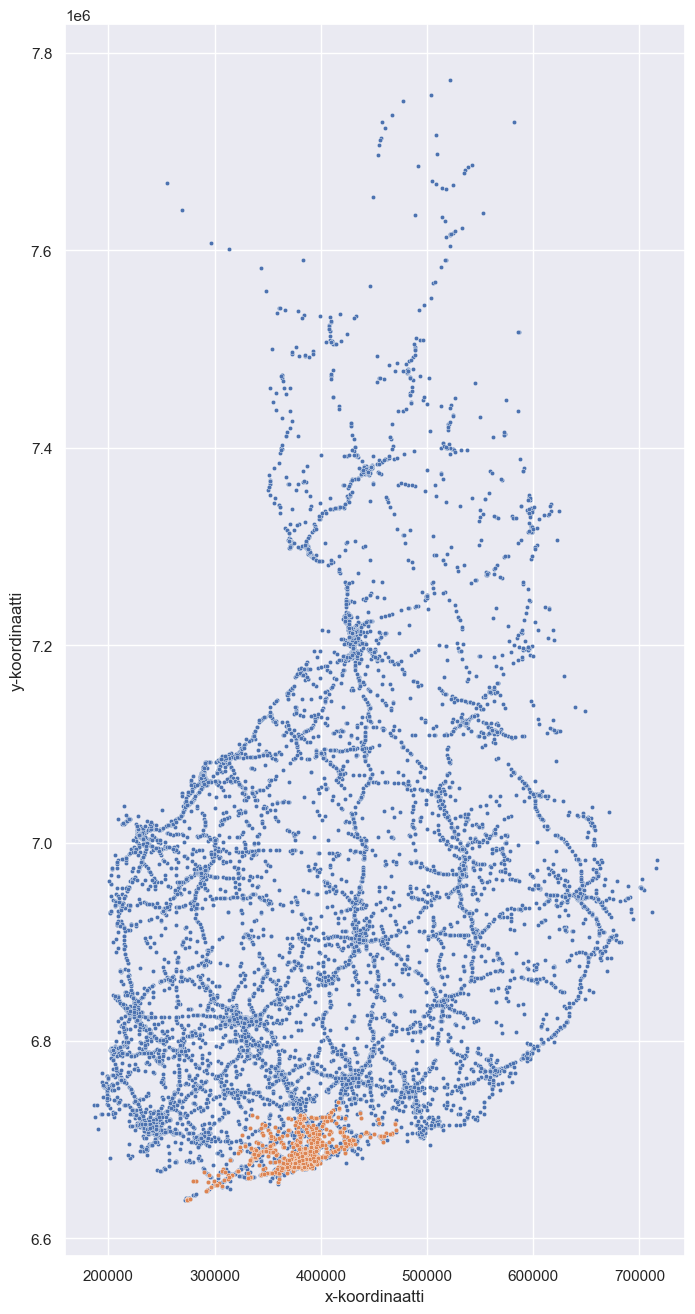

In [7]:
import seaborn as sns

sns.set_theme(rc={'figure.figsize':(8,16)})
ax = sns.scatterplot(data=df_original, x="x-koordinaatti", y="y-koordinaatti", s=10)
sns.scatterplot(data=uusimaa, x="x-koordinaatti", y="y-koordinaatti", s=10, ax=ax)

<Axes: xlabel='x-koordinaatti', ylabel='y-koordinaatti'>

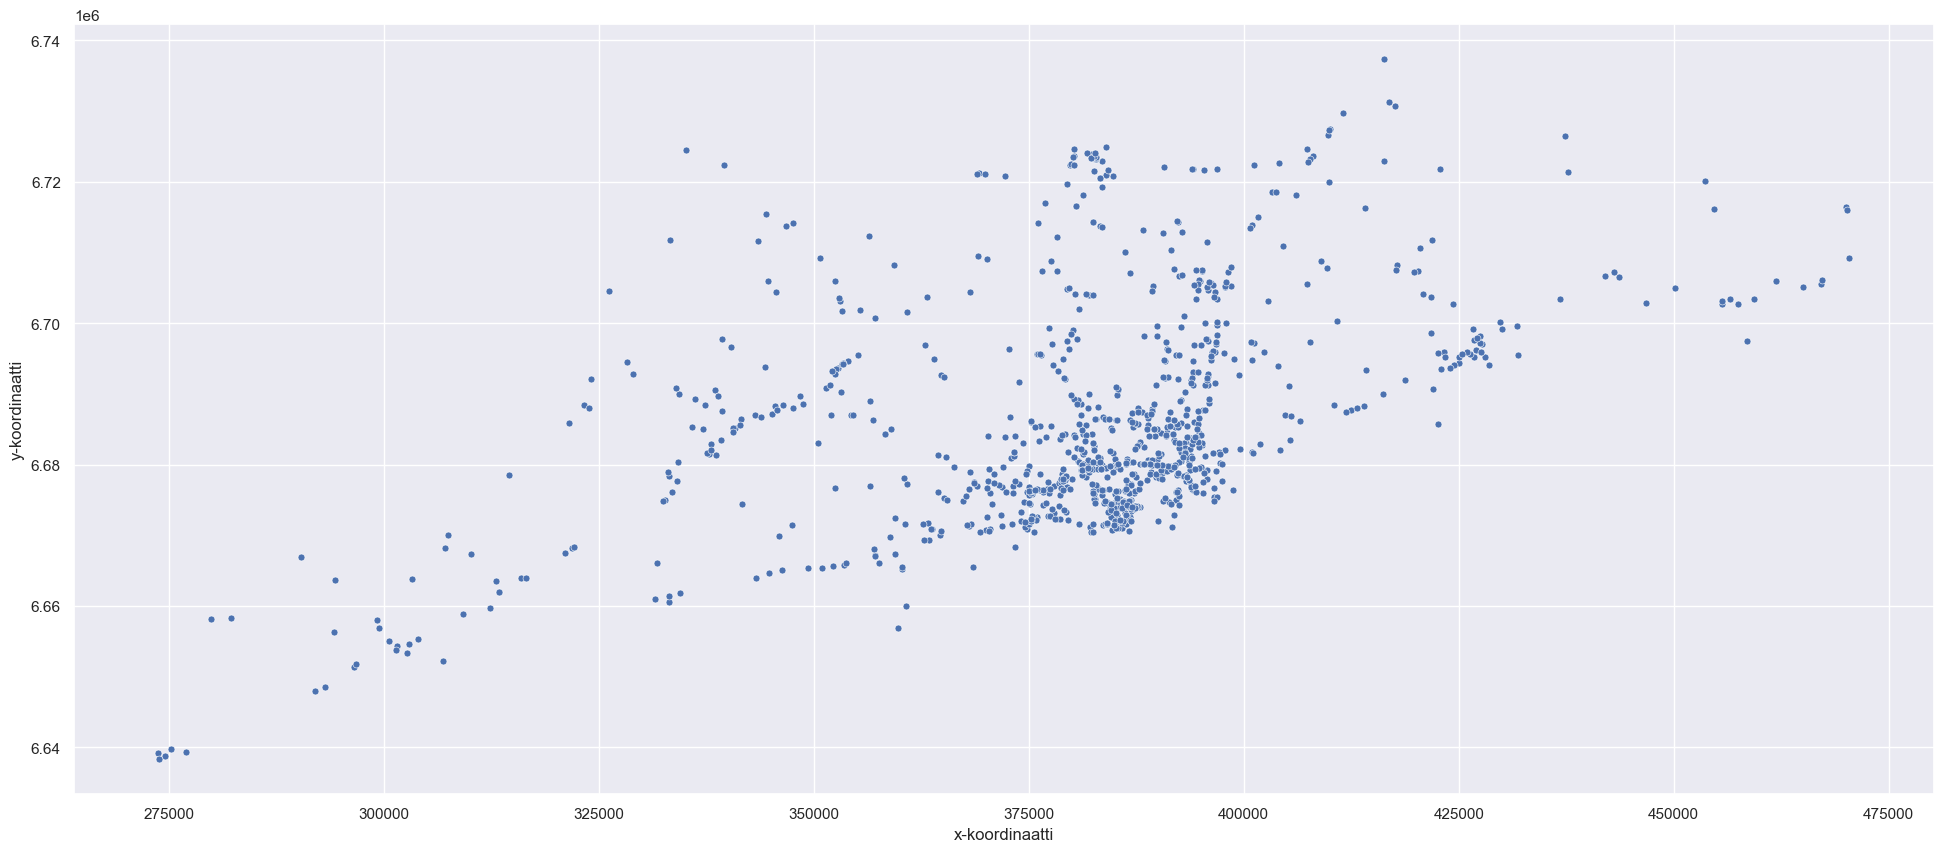

In [8]:
sns.set_theme(rc={'figure.figsize':(24, 10)})
sns.scatterplot(data=uusimaa, x="x-koordinaatti", y="y-koordinaatti", s=25)

In [9]:
u_coordinates = uusimaa.loc[:, ['x-koordinaatti', 'y-koordinaatti']]
u_coordinates

,x-koordinaatti,y-koordinaatti
31,392017.0,6685318.0
38,392858.0,6681503.0
39,389089.0,6687040.0
51,383665.0,6671405.0
77,379482.0,6697489.0
...,...,...
17692,416339.0,6722956.0
17801,393387.0,6678267.0
17811,395484.0,6687717.0
17824,400723.0,6713414.0


In [10]:
from sklearn.cluster import KMeans

model = KMeans(init='random', n_clusters=5, random_state=42)
model.fit(u_coordinates)

KMeans(init='random', n_clusters=5, random_state=42)

In [11]:
centroids = model.cluster_centers_
centroids_df = pd.DataFrame(centroids)
centroids_df

,0,1
0,391249.936047,6.709241e+06
1,300948.666667,6.657601e+06
2,348435.058394,6.684793e+06
3,385326.608764,6.679437e+06
4,432749.473684,6.702309e+06


In [12]:
labels = model.labels_
u_coordinates_alueet = pd.DataFrame(u_coordinates)
u_coordinates_alueet['Alue'] = labels

<Axes: xlabel='x-koordinaatti', ylabel='y-koordinaatti'>

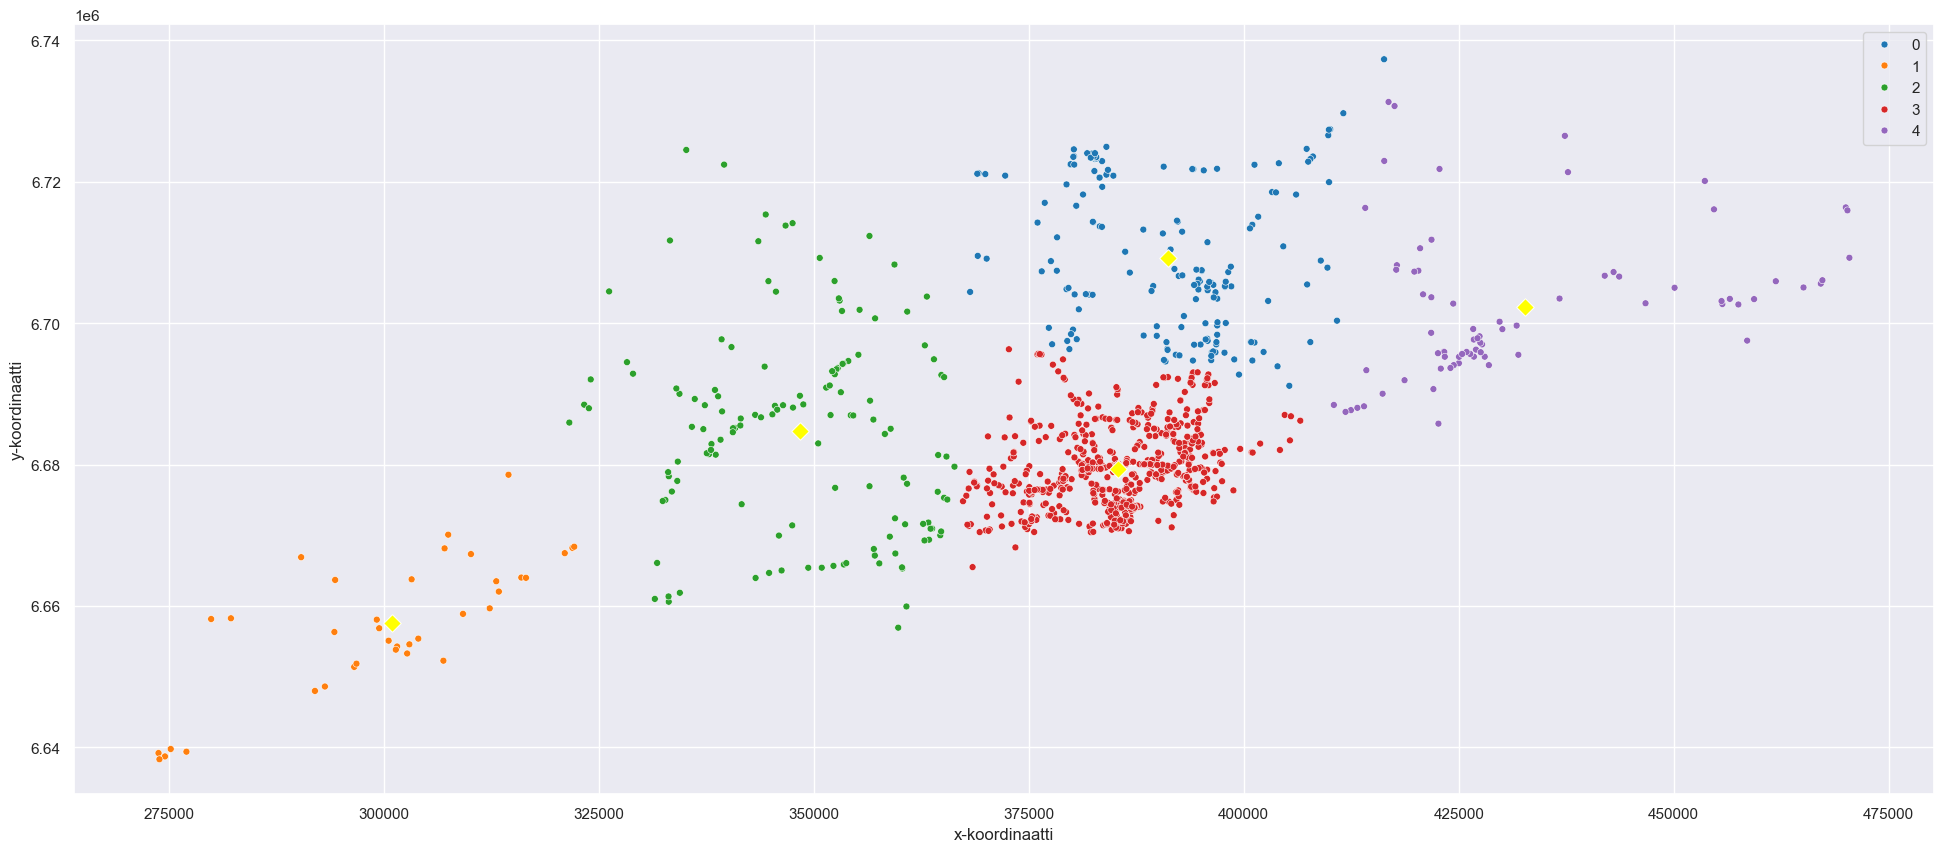

In [13]:
ax = sns.scatterplot(data=u_coordinates_alueet, x="x-koordinaatti", y="y-koordinaatti", s=25, hue='Alue', palette="tab10")
sns.scatterplot(data=centroids_df, x=0, y=1, s=80, ax=ax, marker='D', color='yellow')

In [14]:
from sklearn.metrics import silhouette_score

print('Silhouette score = %.2f' % silhouette_score(u_coordinates_alueet, labels))

Silhouette score = 0.53


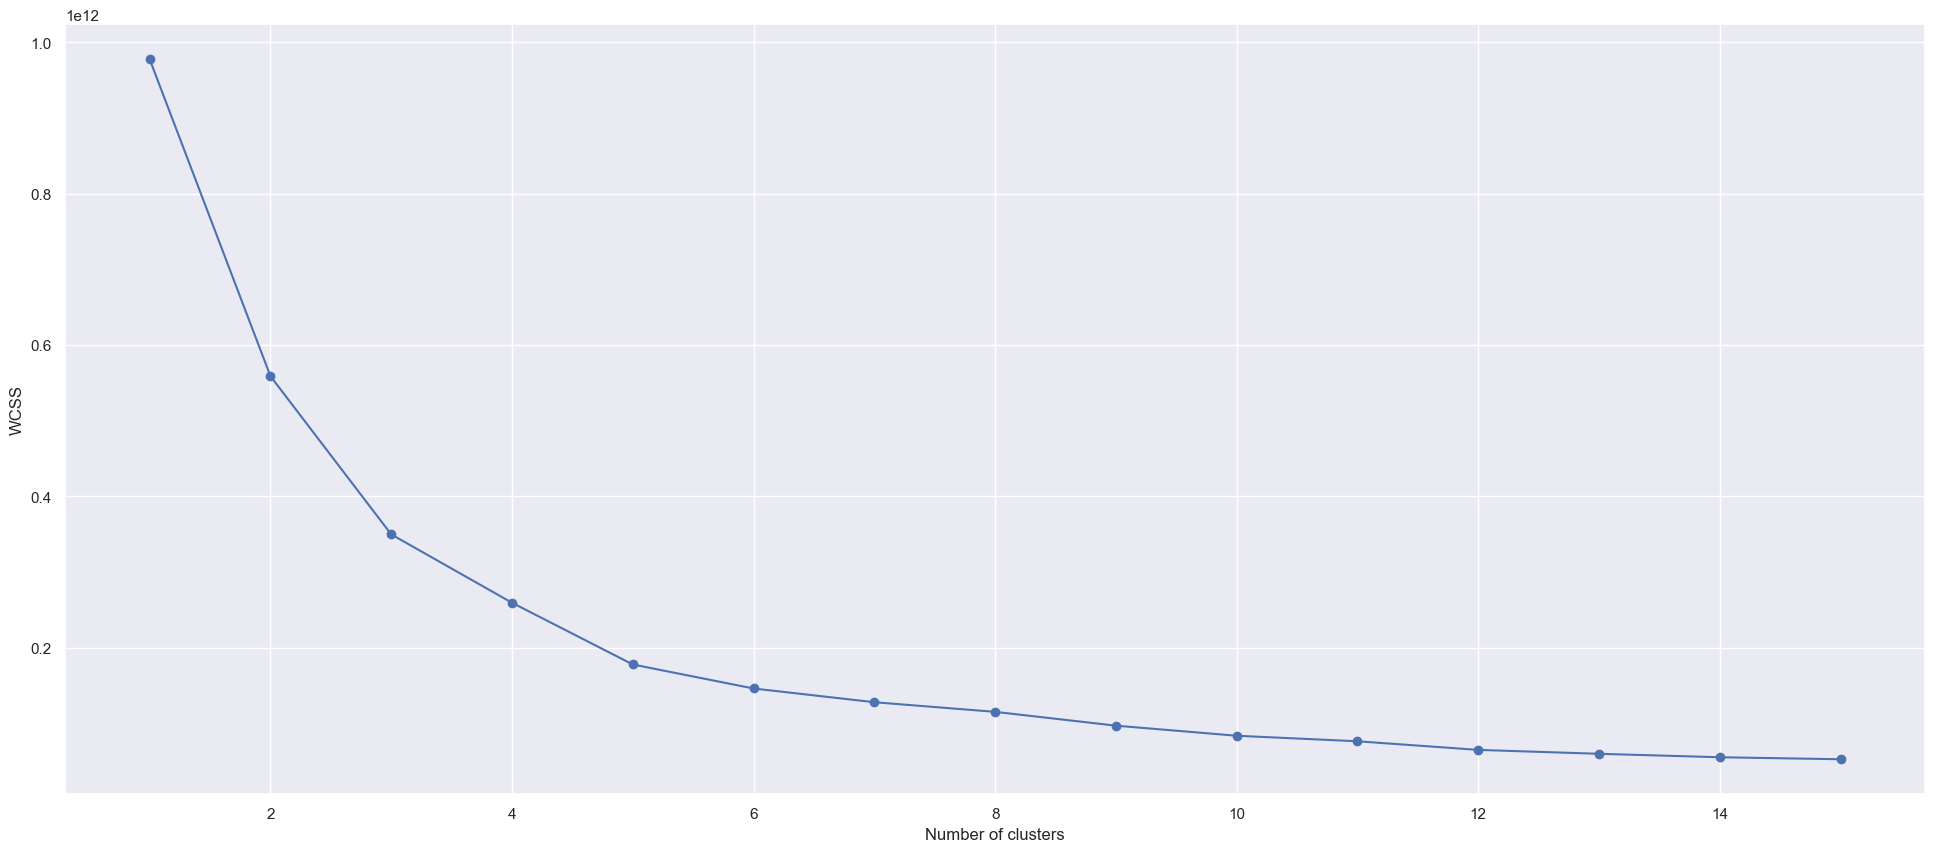

In [15]:
import matplotlib.pyplot as plt

wcss = []
for i in range(1,16):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(u_coordinates)
    wcss.append(model.inertia_)
    
plt.plot(range(1,16), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()